# Logistic Regression

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
import time, warnings, json

# Logistic Regression Model
from sklearn.base import clone
from sklearn.exceptions import ConvergenceWarning
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score

warnings.filterwarnings("default", category=ConvergenceWarning)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

PROCESSED_DIR = Path("../data/processed")
RESULTS_DIR = Path("../results/logistic_regression")
CONFIG_DIR = Path("../configs")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
CONFIG_DIR.mkdir(parents=True, exist_ok=True)

N_SPLITS = 5
RANDOM_SEED = 21352822

print("Processed data:", PROCESSED_DIR.resolve())
print("Results DIR:", RESULTS_DIR.resolve())

Processed data: /Users/ethan/Code Repository/MSDM 5054/Project/Project 1/data/processed
Results DIR: /Users/ethan/Code Repository/MSDM 5054/Project/Project 1/results/logistic_regression


## Load Datasets

In [2]:
train_path = PROCESSED_DIR / "final_train_clean.parquet"
test_path = PROCESSED_DIR / "final_test_clean.parquet"
train_encoded_path = PROCESSED_DIR / "final_train_encoded.parquet"
test_encoded_path = PROCESSED_DIR / "final_test_encoded.parquet"

train, test = pd.read_parquet(train_path), pd.read_parquet(test_path)
train_encoded, test_encoded = pd.read_parquet(train_encoded_path), pd.read_parquet(test_encoded_path)

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("\nTrain_Encoded shape:", train_encoded.shape)
print("Test_Encoded shape:", test_encoded.shape)

Train shape: (307511, 374)
Test shape: (48744, 372)

Train_Encoded shape: (307511, 514)
Test_Encoded shape: (48744, 512)


In [3]:
train_encoded.columns

Index(['SK_ID_CURR', 'TARGET', 'FOLD', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE',
       'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH',
       ...
       'WALLSMATERIAL_MODE_Mixed', 'WALLSMATERIAL_MODE_Monolithic',
       'WALLSMATERIAL_MODE_Others', 'WALLSMATERIAL_MODE_Panel',
       'WALLSMATERIAL_MODE_Stone, brick', 'WALLSMATERIAL_MODE_Wooden',
       'WALLSMATERIAL_MODE_nan', 'EMERGENCYSTATE_MODE_No',
       'EMERGENCYSTATE_MODE_Yes', 'EMERGENCYSTATE_MODE_nan'],
      dtype='str', length=514)

In [4]:
NON_FEATURES = {
    "SK_ID_CURR",
    "TARGET",
    "FOLD"
}

clean_predictors = [
    c for c in train.columns
    if c not in NON_FEATURES
]

encoded_predictors = [
    c for c in train_encoded.columns
    if c not in NON_FEATURES
]

print("Clean predictors:", len(clean_predictors))
print("Encoded predictorsL", len(encoded_predictors))
print("Target rate:", train_encoded["TARGET"].mean())

fold_summary = train_encoded.groupby("FOLD")["TARGET"].agg(rows="size", positives="sum", target_rate="mean")
display(fold_summary)

Clean predictors: 371
Encoded predictorsL 511
Target rate: 0.08072881945686496


,rows,positives,target_rate
FOLD,,,
0,61503,4965,0.080728
1,61502,4965,0.080729
2,61502,4965,0.080729
3,61502,4965,0.080729
4,61502,4965,0.080729


## Feature groups

In [5]:
EXT_RAW = [
    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3",
]

EXT_ENGINEERED = [
    "APP_EXT_SOURCE_MEAN",
    "APP_EXT_SOURCE_MIN",
    "APP_EXT_SOURCE_MAX",
    "APP_EXT_SOURCE_STD",
    "APP_EXT_SOURCE_COUNT"
]

FINANCIAL_RATIO= [
    "APP_CREDIT_INCOME_RATIO",
    "APP_ANNUITY_INCOME_RATIO",
    "APP_CREDIT_ANNUITY_RATIO",
    "APP_CREDIT_GOODS_RATIO",
    "APP_INCOME_PER_PERSON",
    "APP_INCOME_PER_CHILD",
]

HISTORY_PREFIXES = (
    "BURO_", "BB_",
    "PREV_",
    "INST_",
    "CC_",
    "POS_",
    "CROSS_",
)


def existing(features):
    return [
        feature
        for feature in features
        if feature in clean_predictors
    ]

external_socres = existing(EXT_RAW + EXT_ENGINEERED)
history = [c for c in clean_predictors if c.startswith(HISTORY_PREFIXES)]
app_engineered = [c for c in clean_predictors if c.startswith("APP_") and c not in external_socres]
app_original = [c for c in clean_predictors if not c.startswith(HISTORY_PREFIXES) and not c.startswith("APP_") and c not in EXT_RAW]

FEATURE_GROUPS_CLEAN = {
    "APPLICATION_ORIGINAL": app_original,
    "APPLICATION_ENGINEERED": app_engineered,
    "EXTERNAL_SCORES": external_socres,
    "HISTORICAL_CREDIT": history,
    "FINANCIAL_RATIOS": existing(FINANCIAL_RATIO),
    "BUREAU": [c for c in clean_predictors if c.startswith(("BURO_","BB_"))],
    "PREVIOUS": [c for c in clean_predictors if c.startswith("PREV_")],
    "INSTALLMENTS": [c for c in clean_predictors if c.startswith("INST_")],
    "CREDIT_CARD": [c for c in clean_predictors if c.startswith("CC_")],
    "POS": [c for c in clean_predictors if c.startswith("POS_")],
    }

def encoded_columns_for_clean_features(clean_features):
    selected = []
    for enc in encoded_predictors:
        for clean in clean_features:
            if enc == clean or enc.startswith(clean + "_"):
                selected.append(enc)
                break
    return selected

FEATURE_GROUPS_ENCODED = {k: encoded_columns_for_clean_features(v) for k, v in FEATURE_GROUPS_CLEAN.items()}

display(pd.DataFrame([{
    "feature_group": k,
    "n_clean_features": len(FEATURE_GROUPS_CLEAN[k]),
    "n_encoded_features": len(FEATURE_GROUPS_ENCODED[k]),
} for k in FEATURE_GROUPS_CLEAN ]))

,feature_group,n_clean_features,n_encoded_features
0,APPLICATION_ORIGINAL,124,264
1,APPLICATION_ENGINEERED,10,10
2,EXTERNAL_SCORES,8,8
3,HISTORICAL_CREDIT,229,229
4,FINANCIAL_RATIOS,6,6
5,BUREAU,55,55
6,PREVIOUS,41,41
7,INSTALLMENTS,49,49
8,CREDIT_CARD,43,43
9,POS,38,38


## Part A -- Baseline Model

In [6]:
BASELINE_LOGISTIC_PARAMS = {
    "solver": "lbfgs",
    "penalty": "l2",
    "max_iter": 500,
    "C": 1.0,
    "class_weight": None,
    "random_state": RANDOM_SEED
}

BASELINE_LOGISTIC_PARAMS

{'solver': 'lbfgs',
 'penalty': 'l2',
 'max_iter': 500,
 'C': 1.0,
 'class_weight': None,
 'random_state': 21352822}

In [7]:
baseline_logistic_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(**BASELINE_LOGISTIC_PARAMS))
])

baseline_logistic_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto accou

In [8]:
def logistic_pipeline(params=None):
    params = BASELINE_LOGISTIC_PARAMS.copy() if params is None else params.copy()

    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(**params))
    ])

### 5-fold Logistic Regression CV

In [9]:
def logistic_cv(train_df, feature_cols, experiment_name, logistic_params=None):
    params = BASELINE_LOGISTIC_PARAMS.copy() if logistic_params is None else logistic_params.copy()
    rows = []
    oof = np.full(len(train_df), np.nan)
    models = []

    for fold in range(N_SPLITS):

        print(f"\n{experiment_name} | Fold {fold + 1} / {N_SPLITS} | training...", flush=True)

        start = time.time()

        training = train_df["FOLD"] != fold
        validation = train_df["FOLD"] == fold

        X_train = train_df.loc[training, feature_cols]
        y_train = train_df.loc[training, "TARGET"]

        X_validation = train_df.loc[validation, feature_cols]
        y_validation = train_df.loc[validation, "TARGET"]

        model = logistic_pipeline(params)

        convergence_warning = False

        # training model
        with warnings.catch_warnings(record=True) as caught:
            warnings.simplefilter("always", ConvergenceWarning)

            model.fit(X_train, y_train)

            convergence_warning = any(issubclass(warning.category, ConvergenceWarning) for warning in caught)


        pred = model.predict_proba(X_validation)[:, 1]

        oof[np.where(validation.to_numpy())[0]] = pred

        roc = roc_auc_score(y_validation, pred)

        pr = average_precision_score(y_validation, pred)

        lr = model.named_steps["model"]

        n_iter = int(np.max(lr.n_iter_))

        max_iter = int(params["max_iter"])

        converged = (not convergence_warning and n_iter < max_iter)

        rows.append({
            "model": "LogisticRegression",
            "experiment": experiment_name,
            "fold": fold,
            "n_features": len(feature_cols),
            "roc_auc": roc,
            "pr_auc": pr,
            "n_iter": n_iter,
            "max_iter": max_iter,
            "convergence_warning": convergence_warning,
            "converged": converged,
            "seconds": time.time() - start
        })

        models.append(model)

        print(f"{experiment_name} | Fold {fold + 1} | ROC-AUC={roc:.6f} | PR-AUC={pr:.6f} | n_iter={n_iter} | converged={converged}")

    fold_df = pd.DataFrame(rows)

    summary = {
        "experiment": experiment_name,
        "n_features": len(feature_cols),
        "mean_roc_auc": fold_df["roc_auc"].mean(),
        "std_roc_auc": fold_df["roc_auc"].std(),
        "oof_roc_auc": roc_auc_score(train_df["TARGET"], oof),
        "mean_pr_auc": fold_df["pr_auc"].mean(),
        "std_pr_auc": fold_df["pr_auc"].std(),
        "oof_pr_auc": average_precision_score(train_df["TARGET"], oof),
        "all_folds_converged": bool(fold_df["converged"].all()),
        "max_n_iter": int(fold_df["n_iter"].max())
    }

    return {
        "fold_results": fold_df,
        "summary": summary,
        "oof": oof,
        "models": models,
        "params": params
    }

### Run Baseline Model

In [10]:
logistic_features = encoded_predictors

baseline_results = logistic_cv(
    train_df=train_encoded, 
    feature_cols=logistic_features, 
    experiment_name="LR_baseline",
    logistic_params=BASELINE_LOGISTIC_PARAMS
)

baseline_fold_results = (baseline_results["fold_results"])
baseline_summary = pd.DataFrame([baseline_results["summary"]])

display(baseline_fold_results)
display(baseline_summary)


LR_baseline | Fold 1 / 5 | training...
LR_baseline | Fold 1 | ROC-AUC=0.772824 | PR-AUC=0.260713 | n_iter=77 | converged=True

LR_baseline | Fold 2 / 5 | training...
LR_baseline | Fold 2 | ROC-AUC=0.777967 | PR-AUC=0.260706 | n_iter=74 | converged=True

LR_baseline | Fold 3 / 5 | training...
LR_baseline | Fold 3 | ROC-AUC=0.772606 | PR-AUC=0.253692 | n_iter=77 | converged=True

LR_baseline | Fold 4 / 5 | training...
LR_baseline | Fold 4 | ROC-AUC=0.780165 | PR-AUC=0.271305 | n_iter=74 | converged=True

LR_baseline | Fold 5 / 5 | training...
LR_baseline | Fold 5 | ROC-AUC=0.784864 | PR-AUC=0.271570 | n_iter=81 | converged=True


,model,experiment,fold,n_features,roc_auc,pr_auc,n_iter,max_iter,convergence_warning,converged,seconds
0,LogisticRegression,LR_baseline,0,511,0.772824,0.260713,77,500,False,True,14.528845
1,LogisticRegression,LR_baseline,1,511,0.777967,0.260706,74,500,False,True,14.794827
2,LogisticRegression,LR_baseline,2,511,0.772606,0.253692,77,500,False,True,14.110501
3,LogisticRegression,LR_baseline,3,511,0.780165,0.271305,74,500,False,True,13.641828
4,LogisticRegression,LR_baseline,4,511,0.784864,0.271570,81,500,False,True,14.436373


,experiment,n_features,mean_roc_auc,std_roc_auc,oof_roc_auc,mean_pr_auc,std_pr_auc,oof_pr_auc,all_folds_converged,max_n_iter
0,LR_baseline,511,0.777685,0.005177,0.777662,0.263597,0.007710,0.263201,True,81


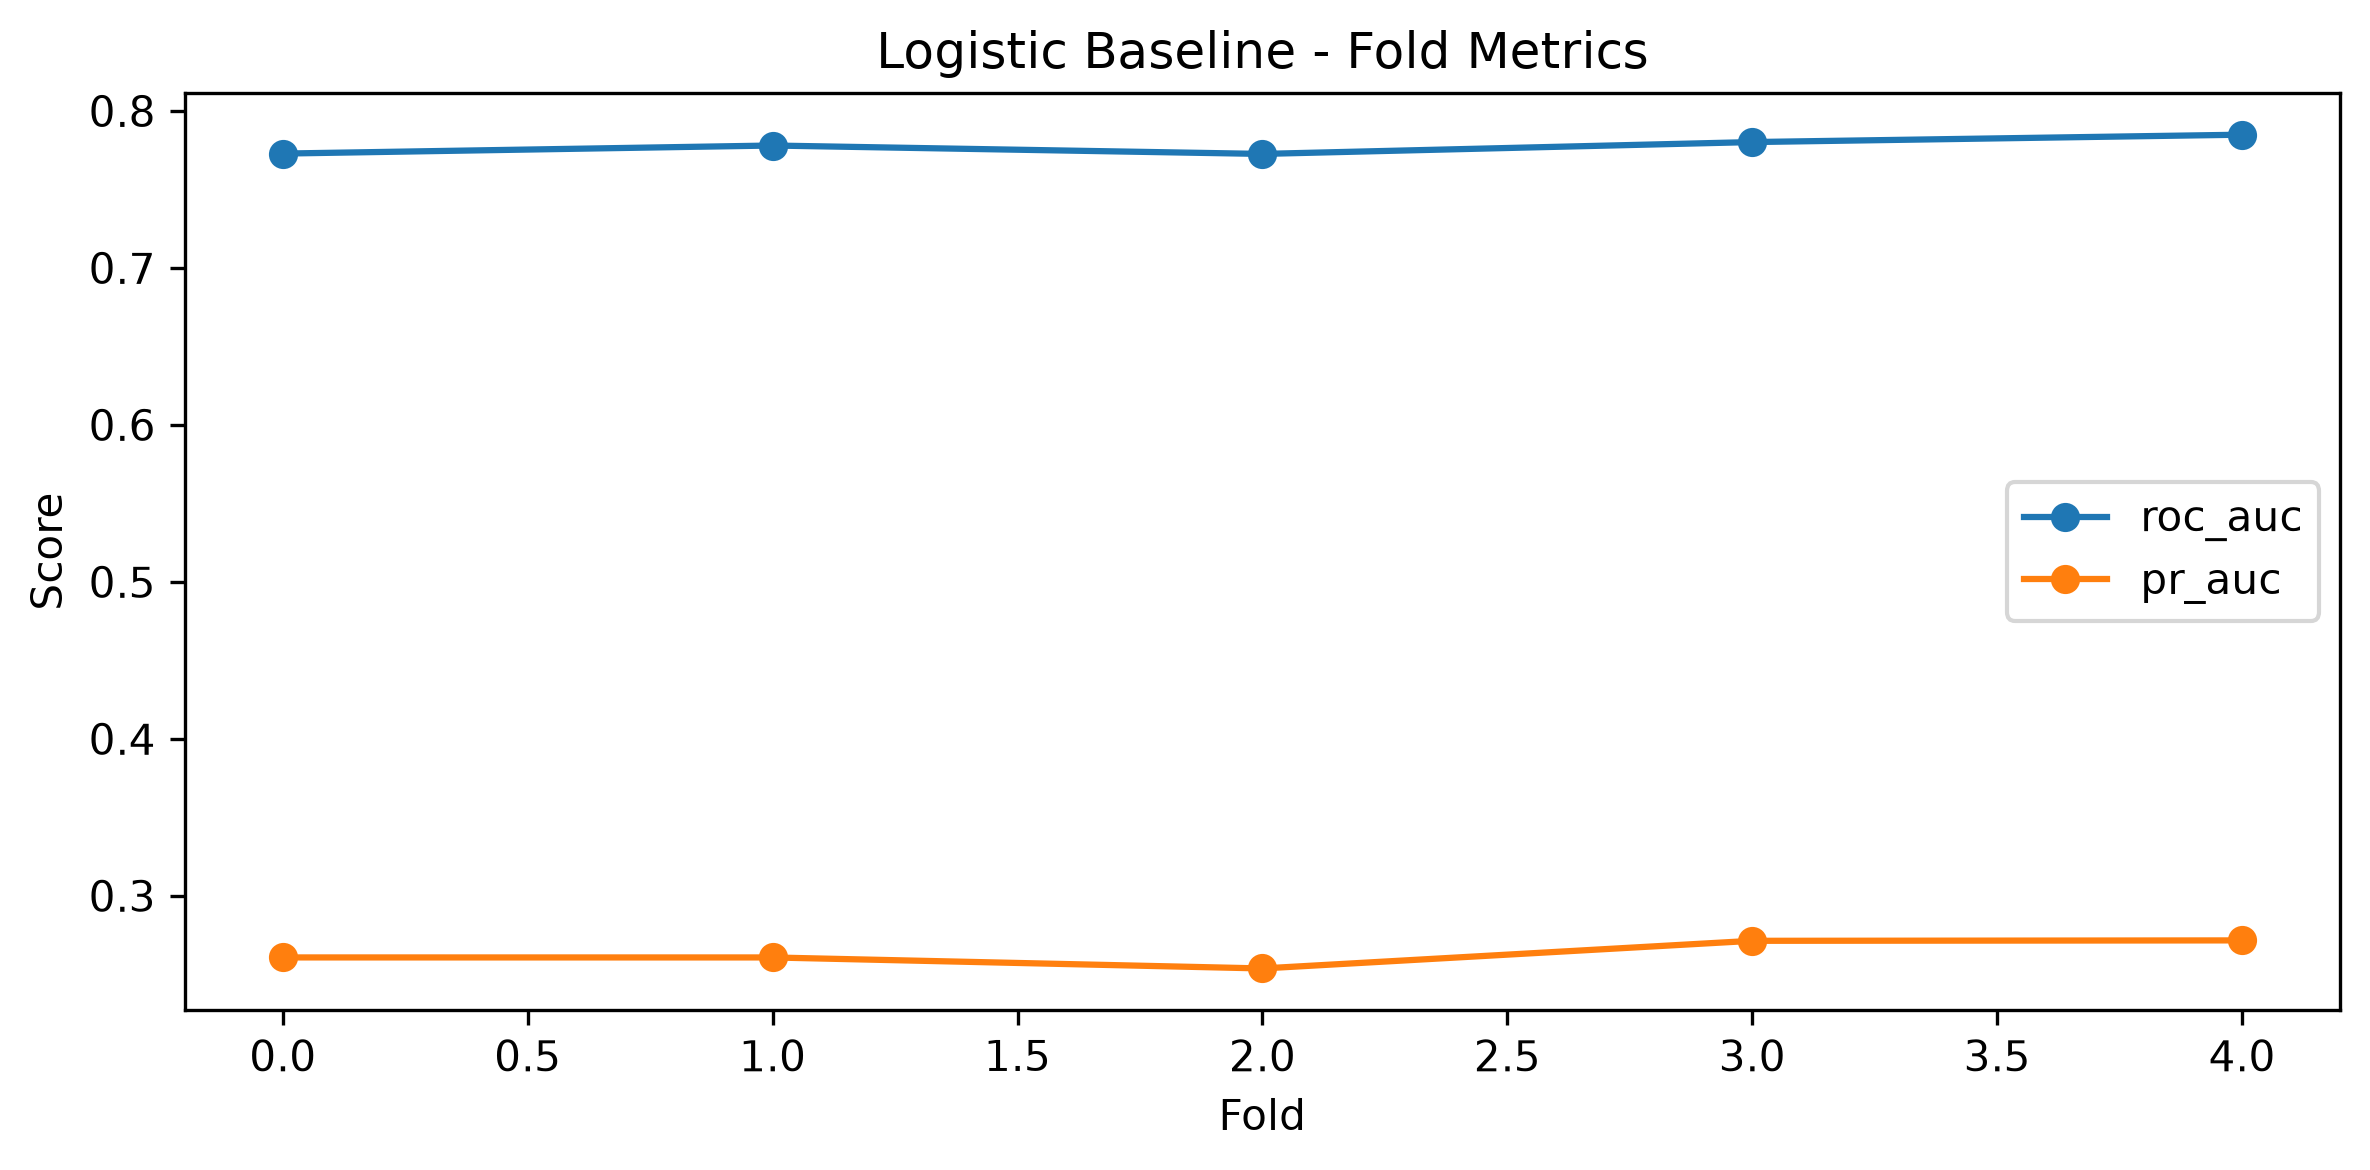

,fold,n_iter,max_iter,convergence_warning,converged
0,0,77,500,False,True
1,1,74,500,False,True
2,2,77,500,False,True
3,3,74,500,False,True
4,4,81,500,False,True


In [11]:
fig, ax = plt.subplots(figsize=(8, 4), dpi=300)

baseline_fold_results.plot(
    x="fold",
    y=["roc_auc", "pr_auc"],
    marker="o",
    ax=ax
)

ax.set_title("Logistic Baseline - Fold Metrics")
ax.set_xlabel("Fold")
ax.set_ylabel("Score")

plt.tight_layout()
plt.show()

display(baseline_fold_results[["fold", "n_iter", "max_iter", "convergence_warning", "converged"]])

## Part B -- L2 Regularization

### Search Parameter `C`

In [12]:
C_VALUES = [0.001, 0.01, 0.1, 1.0, 10.0]

c_search_rows = []
c_search_fold_parts = []

for C_value in C_VALUES:
    params = {
        "solver": "lbfgs",
        "penalty": "l2",
        "max_iter": 1000,
        "C": C_value,
        "class_weight": None,
        "random_state": RANDOM_SEED
    }

    print("\n"+"=" * 72)
    print(f"L2 Regularization Logistic Regression | C={C_value}")
    print("=" * 72)

    result = logistic_cv(
        train_df=train_encoded,
        feature_cols=logistic_features,
        experiment_name=(f"LR_L2_C_{C_value}"),
        logistic_params=params,
    )

    row = result["summary"].copy()
    row["C"] = C_value
    c_search_rows.append(row)
    f = result["fold_results"].copy()
    f["C"] = C_value
    c_search_fold_parts.append(f)

c_search_summary = pd.DataFrame(c_search_rows).sort_values("C").reset_index(drop=True)
c_search_folds = pd.concat(c_search_fold_parts, ignore_index=True)

display(c_search_summary[[
    "C",
    "mean_roc_auc",
    "std_roc_auc",
    "oof_roc_auc",
    "mean_pr_auc",
    "std_pr_auc",
    "oof_pr_auc",
    "all_folds_converged",
    "max_n_iter"
]])


L2 Regularization Logistic Regression | C=0.001

LR_L2_C_0.001 | Fold 1 / 5 | training...
LR_L2_C_0.001 | Fold 1 | ROC-AUC=0.772495 | PR-AUC=0.260564 | n_iter=33 | converged=True

LR_L2_C_0.001 | Fold 2 / 5 | training...
LR_L2_C_0.001 | Fold 2 | ROC-AUC=0.778147 | PR-AUC=0.261073 | n_iter=29 | converged=True

LR_L2_C_0.001 | Fold 3 / 5 | training...
LR_L2_C_0.001 | Fold 3 | ROC-AUC=0.772597 | PR-AUC=0.253799 | n_iter=28 | converged=True

LR_L2_C_0.001 | Fold 4 / 5 | training...
LR_L2_C_0.001 | Fold 4 | ROC-AUC=0.779988 | PR-AUC=0.271740 | n_iter=31 | converged=True

LR_L2_C_0.001 | Fold 5 / 5 | training...
LR_L2_C_0.001 | Fold 5 | ROC-AUC=0.784897 | PR-AUC=0.273150 | n_iter=29 | converged=True

L2 Regularization Logistic Regression | C=0.01

LR_L2_C_0.01 | Fold 1 / 5 | training...
LR_L2_C_0.01 | Fold 1 | ROC-AUC=0.772859 | PR-AUC=0.260682 | n_iter=56 | converged=True

LR_L2_C_0.01 | Fold 2 / 5 | training...
LR_L2_C_0.01 | Fold 2 | ROC-AUC=0.778146 | PR-AUC=0.260819 | n_iter=51 | conve

,C,mean_roc_auc,std_roc_auc,oof_roc_auc,mean_pr_auc,std_pr_auc,oof_pr_auc,all_folds_converged,max_n_iter
0,0.001000,0.777625,0.005252,0.777602,0.264065,0.008186,0.263658,True,33
1,0.010000,0.777869,0.005152,0.777850,0.264007,0.007839,0.263608,True,56
2,0.100000,0.777666,0.005182,0.777648,0.263590,0.007748,0.263182,True,76
3,1.000000,0.777685,0.005177,0.777662,0.263597,0.007710,0.263201,True,81
4,10.000000,0.777686,0.005188,0.777663,0.263599,0.007690,0.263185,True,86


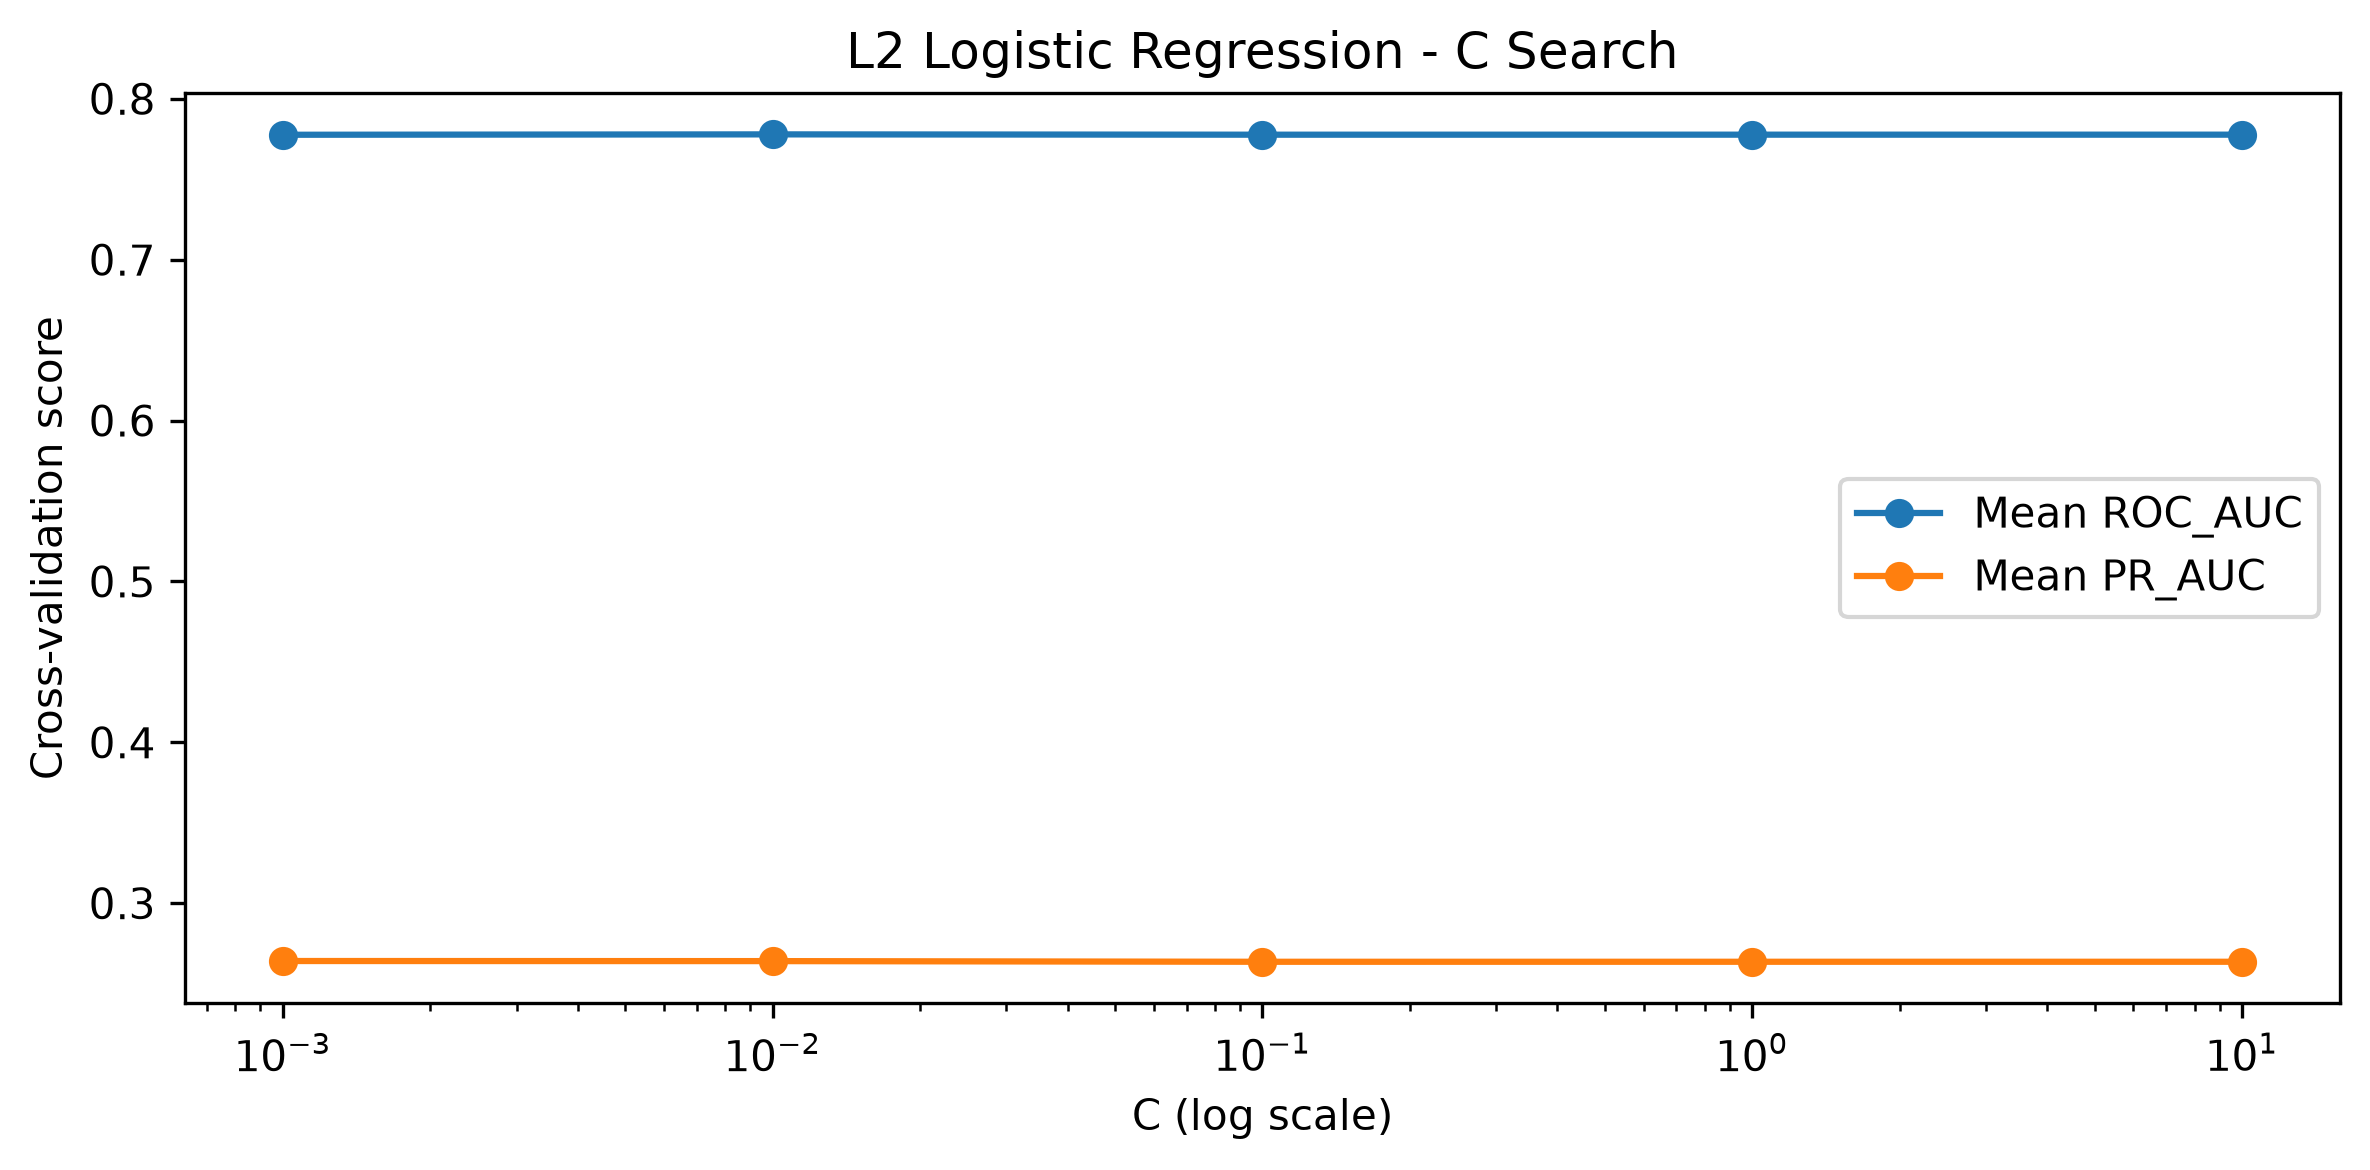

In [13]:
fig, ax = plt.subplots(figsize=(8, 4), dpi=300)

ax.plot(
    c_search_summary["C"],
    c_search_summary["mean_roc_auc"],
    marker="o",
    label="Mean ROC_AUC"
)

ax.plot(
    c_search_summary["C"],
    c_search_summary["mean_pr_auc"],
    marker="o",
    label="Mean PR_AUC"
)

ax.set_title("L2 Logistic Regression - C Search")
ax.set_xlabel("C (log scale)")
ax.set_ylabel("Cross-validation score")
ax.set_xscale("log")
ax.legend()

plt.tight_layout()
plt.show()

In [14]:
TUNING_TOLERANCE = 0.0002

candidates = c_search_summary[c_search_summary["all_folds_converged"]].copy()

if candidates.empty:
    raise RuntimeError

best = candidates["mean_roc_auc"].max()

near_best = candidates[candidates.mean_roc_auc >= best - TUNING_TOLERANCE].sort_values("C")
SELECTED_L2_C = float(near_best.iloc[0].C)

print("Selected L2 C:", SELECTED_L2_C)

Selected L2 C: 0.01


## Part C -- Compare L1, L2 and Elastic Net

In [15]:
REGULARIZATION_CONFIGS = [
    {
        "name": "L2",
        "params": {
            "solver": "lbfgs",
            "penalty": "l2",
            "C": SELECTED_L2_C,
            "max_iter": 2000,
            "class_weight": None,
            "random_state": RANDOM_SEED
        }
    },

    {
        "name": "L1",
        "params": {
            "solver": "saga",
            "penalty": "l1",
            "C": SELECTED_L2_C,
            "max_iter": 2000,
            "class_weight": None,
            "random_state": RANDOM_SEED
        }
    },

    {
        "name": "ElasticNet_0.5",
        "params": {
            "solver": "saga",
            "penalty": "elasticnet",
            "l1_ratio": 0.5,
            "C": SELECTED_L2_C,
            "max_iter": 2000,
            "class_weight": None,
            "random_state": RANDOM_SEED
        }
    }
]


regularization_rows = []
regularization_runs = []


total_models = len(REGULARIZATION_CONFIGS)

for model_number, cfg in enumerate(REGULARIZATION_CONFIGS, start=1):

    print("\n" + "=" * 72)
    print(f"Regularization {model_number}/{total_models}: {cfg['name']}")
    print(f"C = {cfg['params']['C']}")
    print(f"Solver = {cfg['params']['solver']}")
    print("=" * 72, flush=True)

    result = logistic_cv(
        train_df=train_encoded,
        feature_cols=logistic_features,
        experiment_name=(f"LR_{cfg['name']}"),
        logistic_params=cfg["params"],
    )

    regularization_runs.append({
        "name": cfg["name"],
        "result": result
    })

    row = result["summary"].copy()
    row["regularization"] = cfg["name"]
    regularization_rows.append(row)


regularization_summary = (
    pd.DataFrame(regularization_rows)
    .sort_values(
        "mean_roc_auc",
        ascending=False
    )
    .reset_index(drop=True)
)


print("\n" + "=" * 72)
print("Regularization comparison completed")
print("=" * 72)


Regularization 1/3: L2
C = 0.01
Solver = lbfgs

LR_L2 | Fold 1 / 5 | training...
LR_L2 | Fold 1 | ROC-AUC=0.772859 | PR-AUC=0.260682 | n_iter=56 | converged=True

LR_L2 | Fold 2 / 5 | training...
LR_L2 | Fold 2 | ROC-AUC=0.778146 | PR-AUC=0.260819 | n_iter=51 | converged=True

LR_L2 | Fold 3 / 5 | training...
LR_L2 | Fold 3 | ROC-AUC=0.772939 | PR-AUC=0.254334 | n_iter=50 | converged=True

LR_L2 | Fold 4 / 5 | training...
LR_L2 | Fold 4 | ROC-AUC=0.780465 | PR-AUC=0.272031 | n_iter=56 | converged=True

LR_L2 | Fold 5 / 5 | training...
LR_L2 | Fold 5 | ROC-AUC=0.784938 | PR-AUC=0.272168 | n_iter=56 | converged=True

Regularization 2/3: L1
C = 0.01
Solver = saga

LR_L1 | Fold 1 / 5 | training...
LR_L1 | Fold 1 | ROC-AUC=0.772275 | PR-AUC=0.261687 | n_iter=1016 | converged=True

LR_L1 | Fold 2 / 5 | training...
LR_L1 | Fold 2 | ROC-AUC=0.778064 | PR-AUC=0.260249 | n_iter=733 | converged=True

LR_L1 | Fold 3 / 5 | training...
LR_L1 | Fold 3 | ROC-AUC=0.772165 | PR-AUC=0.254166 | n_iter=10

In [16]:
print(regularization_summary.columns.tolist())

['experiment', 'n_features', 'mean_roc_auc', 'std_roc_auc', 'oof_roc_auc', 'mean_pr_auc', 'std_pr_auc', 'oof_pr_auc', 'all_folds_converged', 'max_n_iter', 'regularization']


In [17]:
display(
    regularization_summary[
        [
            "regularization",
            "mean_roc_auc",
            "std_roc_auc",
            "oof_roc_auc",
            "mean_pr_auc",
            "std_pr_auc",
            "oof_pr_auc",
            "all_folds_converged",
            "max_n_iter",
        ]
    ]
)

,regularization,mean_roc_auc,std_roc_auc,oof_roc_auc,mean_pr_auc,std_pr_auc,oof_pr_auc,all_folds_converged,max_n_iter
0,ElasticNet_0.5,0.778034,0.005156,0.778015,0.264672,0.007907,0.264254,True,1350
1,L2,0.777869,0.005152,0.777850,0.264007,0.007839,0.263608,True,56
2,L1,0.777307,0.005119,0.777287,0.264148,0.007988,0.263735,True,1328


## Best Parameters Model

In [22]:
BEST_LOGISTIC_PARAMS = {
    "solver": "saga",
    "penalty": "elasticnet",
    "l1_ratio": 0.5,
    "C": SELECTED_L2_C,
    "max_iter": 2000,
    "class_weight": None,
    "random_state": RANDOM_SEED
}

logistic_pipeline(BEST_LOGISTIC_PARAMS)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto accou

In [20]:
best_rsult = logistic_cv(
    train_df=train_encoded,
    feature_cols=logistic_features,
    experiment_name="BEST_PARAMS_LR_MODEL",
    logistic_params=BEST_LOGISTIC_PARAMS,
)
best_fold_results = best_rsult["fold_results"]
best_summary = pd.DataFrame([best_rsult["summary"]])
display(best_fold_results)
display(best_summary)


BEST_PARAMS_LR_MODEL | Fold 1 / 5 | training...
BEST_PARAMS_LR_MODEL | Fold 1 | ROC-AUC=0.772912 | PR-AUC=0.262058 | n_iter=1114 | converged=True

BEST_PARAMS_LR_MODEL | Fold 2 / 5 | training...
BEST_PARAMS_LR_MODEL | Fold 2 | ROC-AUC=0.778629 | PR-AUC=0.261264 | n_iter=779 | converged=True

BEST_PARAMS_LR_MODEL | Fold 3 / 5 | training...
BEST_PARAMS_LR_MODEL | Fold 3 | ROC-AUC=0.773023 | PR-AUC=0.254612 | n_iter=958 | converged=True

BEST_PARAMS_LR_MODEL | Fold 4 / 5 | training...
BEST_PARAMS_LR_MODEL | Fold 4 | ROC-AUC=0.780669 | PR-AUC=0.271958 | n_iter=1350 | converged=True

BEST_PARAMS_LR_MODEL | Fold 5 / 5 | training...
BEST_PARAMS_LR_MODEL | Fold 5 | ROC-AUC=0.784940 | PR-AUC=0.273468 | n_iter=1306 | converged=True


,model,experiment,fold,n_features,roc_auc,pr_auc,n_iter,max_iter,convergence_warning,converged,seconds
0,LogisticRegression,BEST_PARAMS_LR_MODEL,0,511,0.772912,0.262058,1114,2000,False,True,612.679192
1,LogisticRegression,BEST_PARAMS_LR_MODEL,1,511,0.778629,0.261264,779,2000,False,True,447.954476
2,LogisticRegression,BEST_PARAMS_LR_MODEL,2,511,0.773023,0.254612,958,2000,False,True,572.999067
3,LogisticRegression,BEST_PARAMS_LR_MODEL,3,511,0.780669,0.271958,1350,2000,False,True,783.209525
4,LogisticRegression,BEST_PARAMS_LR_MODEL,4,511,0.784940,0.273468,1306,2000,False,True,768.572081


,experiment,n_features,mean_roc_auc,std_roc_auc,oof_roc_auc,mean_pr_auc,std_pr_auc,oof_pr_auc,all_folds_converged,max_n_iter
0,BEST_PARAMS_LR_MODEL,511,0.778034,0.005156,0.778015,0.264672,0.007907,0.264254,True,1350


## Export

### Model Config

In [21]:
LOGISTIC_CONFIG = {
    "model_name": "logistic_regression",
    "dataset_version": "encoded",
    "preprocessing": {
        "numeric_imputation": "median",
        "scaling": "StandardScaler",
        "preprocessing_scope": "fit separately within each training fold",
    },
    "hyperparameters": BEST_LOGISTIC_PARAMS,
    "non_predictor_columns": ["SK_ID_CURR", "TARGET", "FOLD"],
    "cv": {
        "fold_column" : "FOLD",
        "n_splits": N_SPLITS,
        "using_existing_folds": True,
    },
    "metrics": ["roc_auc", "average_precision"],
}
config_path = CONFIG_DIR/"logistic.json"
with config_path.open("w", encoding="utf-8") as f:
    json.dump(LOGISTIC_CONFIG, f, indent=2)
print("Saved:", config_path)
LOGISTIC_CONFIG


Saved: ../configs/logistic.json


{'model_name': 'logistic_regression',
 'dataset_version': 'encoded',
 'preprocessing': {'numeric_imputation': 'median',
  'scaling': 'StandardScaler',
  'preprocessing_scope': 'fit separately within each training fold'},
 'hyperparameters': {'solver': 'saga',
  'penalty': 'elasticnet',
  'l1_ratio': 0.5,
  'C': 0.01,
  'max_iter': 2000,
  'class_weight': None,
  'random_state': 21352822},
 'non_predictor_columns': ['SK_ID_CURR', 'TARGET', 'FOLD'],
 'cv': {'fold_column': 'FOLD', 'n_splits': 5, 'using_existing_folds': True},
 'metrics': ['roc_auc', 'average_precision']}

### Model Results

In [23]:
baseline_fold_results.to_csv(RESULTS_DIR/"logistic_baseline_fold_results.csv", index=False)
baseline_summary.to_csv(RESULTS_DIR/"logistic_baseline_summary.csv", index=False)

c_search_folds.to_csv(RESULTS_DIR/"logistic_c_search_fold.csv", index=False)
c_search_summary.to_csv(RESULTS_DIR/"logistic_c_search_summary.csv", index=False)

best_fold_results.to_csv(RESULTS_DIR/"logistic_fold_results.csv", index=False)
best_summary.to_csv(RESULTS_DIR/"logistic_summary.csv", index=False)

In [24]:
print("Saved Logistic Regression outputs to:",RESULTS_DIR.resolve())

Saved Logistic Regression outputs to: /Users/ethan/Code Repository/MSDM 5054/Project/Mini-Project 1/results/logistic_regression
